# Naïve Bayes gaussiano — demo WDBC

Classificazione **binaria** (maligno / benigno) sul dataset Breast Cancer Wisconsin, con il `GaussianNaiveBayes` scritto **da zero** (solo numpy). Tutto coerente con le slide del corso (deck *11.BayesianLearning* e *8.ML_Evaluation*).

## 1. Setup e caricamento dati

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # rende importabile il package src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tutto il codice sorgente
from src.naive_bayes import GaussianNaiveBayes
from src.metrics import (confusion_matrix, accuracy, precision, recall,
                         f1_score, classification_report)
from src.model_selection import kfold_indices

df = pd.read_csv('../data/raw/wdbc.csv')
feat = [c for c in df.columns if c not in ('target', 'diagnosis')]
X = df[feat].values            # 30 feature numeriche
y = df['target'].values        # 0 = maligno, 1 = benigno
POS = 0                        # classe positiva = maligno (quella da individuare)
print('shape:', df.shape, '|', len(feat), 'feature')
df[['diagnosis'] + feat[:6]].head()

shape: (569, 32) | 30 feature


,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,malignant,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,malignant,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,malignant,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,malignant,11.42,20.38,77.58,386.1,0.14250,0.28390
4,malignant,20.29,14.34,135.10,1297.0,0.10030,0.13280


## 2. Esplorazione dei dati (EDA)

Due cose da notare: le classi sono **sbilanciate** (più benigni che maligni) e le feature hanno **scale molto diverse** — ma per Naïve Bayes la scala non conta (ogni feature ha la sua gaussiana per classe).

In [2]:
# bilanciamento delle classi
print(df['diagnosis'].value_counts())
print('\nquota benigni: %.1f%%' %
      (100 * (y == 1).mean()))

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

quota benigni: 62.7%


## 3. Split train/test (niente standardizzazione)

Si usa lo stesso split (seed 42, 30% test). **Non** si standardizza: Naïve Bayes è invariante alla scala, perché stima media e varianza separatamente per ogni feature.

In [3]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
n_test = int(0.3 * len(X))
test_idx, train_idx = idx[:n_test], idx[n_test:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print('train:', X_train.shape, ' test:', X_test.shape)

train: (399, 30)  test: (170, 30)


## 4. Addestramento (Naïve Bayes da zero)

Il `fit` calcola in **forma chiusa**, in una sola passata: i priori P(c), e media/varianza di ogni feature per ciascuna classe. Niente gradient descent.

In [4]:
nb = GaussianNaiveBayes().fit(X_train, y_train)
print('classi:', nb.classes_, '  (0=maligno, 1=benigno)')
print('priori P(c):', np.round(nb.priors_, 3))
# esempio: mu e sigma della feature piu' discriminante, per le due classi
j = np.argsort(np.abs(nb.theta_[0]-nb.theta_[1]) / np.sqrt(0.5*(nb.var_[0]+nb.var_[1])))[::-1][0]
print(f'\nfeature piu\' discriminante: {feat[j]!r}')
print('  maligno : mu=%.3f  sigma=%.3f' % (nb.theta_[0, j], np.sqrt(nb.var_[0, j])))
print('  benigno : mu=%.3f  sigma=%.3f' % (nb.theta_[1, j], np.sqrt(nb.var_[1, j])))

classi: [0 1]   (0=maligno, 1=benigno)
priori P(c): [0.378 0.622]

feature piu' discriminante: 'worst concave points'
  maligno : mu=0.184  sigma=0.046
  benigno : mu=0.077  sigma=0.036


### Come classifica una singola biopsia (regola MAP)

Si vede *come* il modello arriva alla diagnosi su un caso concreto: per ogni classe somma `log P(c)` e le log-verosimiglianze di tutte le feature, e sceglie il **punteggio più grande**. Calcolo reale dietro l'esempio illustrativo delle slide.

In [5]:
i_mal, i_ben = list(nb.classes_).index(0), list(nb.classes_).index(1)

# scegliamo una biopsia MALIGNA del test set, classificata con alta confidenza
mal = np.where(y_test == 0)[0]
k = mal[np.argmax(nb.predict_proba(X_test[mal])[:, i_mal])]
x = X_test[k]

# log-verosimiglianza gaussiana di una feature per una classe
def log_gauss(ic, j):
    v = nb.var_[ic, j]
    return -0.5 * (np.log(2*np.pi*v) + (x[j] - nb.theta_[ic, j])**2 / v)

# tabella: prior + 2 feature illustrative + punteggio totale (tutte le 30 feature)
righe = {'log P(c)  (prior)': [np.log(nb.priors_[i_mal]), np.log(nb.priors_[i_ben])]}
for nome in ['worst concave points', 'worst perimeter']:
    j = feat.index(nome)
    righe[f'logN({nome} = {x[j]:.2f})'] = [log_gauss(i_mal, j), log_gauss(i_ben, j)]
jll = nb._joint_log_likelihood(X_test[k:k+1])[0]
righe['PUNTEGGIO (tutte le 30 feature)'] = [jll[i_mal], jll[i_ben]]

tab = pd.DataFrame(righe, index=['maligno', 'benigno']).T.round(2)
print('etichetta reale:', 'maligno' if y_test[k] == 0 else 'benigno')
print(tab.to_string())
print('\nP(maligno|x) = %.6f  ->  predetto: %s' % (
    nb.predict_proba(X_test[k:k+1])[0][i_mal],
    'maligno' if nb.predict(X_test[k:k+1])[0] == 0 else 'benigno'))

etichetta reale: maligno
                                   maligno  benigno
log P(c)  (prior)                    -0.97    -0.48
logN(worst concave points = 0.15)     1.81     0.61
logN(worst perimeter = 134.90)       -4.38    -9.62
PUNTEGGIO (tutte le 30 feature)       4.31   -38.25

P(maligno|x) = 1.000000  ->  predetto: maligno


## 5. Valutazione sul test set

In [6]:
y_pred = nb.predict(X_test)
rep = classification_report(y_test, y_pred, pos_label=POS)
{k: round(float(v), 4) for k, v in rep.items()}

{'accuracy': 0.9176, 'precision': 0.8983, 'recall': 0.8689, 'f1': 0.8833}

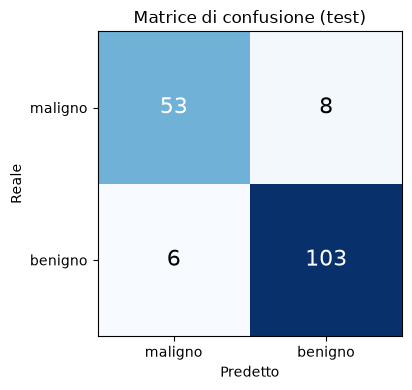

Falsi negativi (maligni mancati): 8  -> recall maligno = 0.869


In [7]:
C = confusion_matrix(y_test, y_pred, labels=[0, 1])   # [[TP,FN],[FP,TN]] con pos=maligno
labels = ['maligno', 'benigno']
plt.figure(figsize=(4.6, 4))
plt.imshow(C, cmap='Blues')
for i in range(2):
    for k in range(2):
        plt.text(k, i, str(C[i, k]), ha='center', va='center', fontsize=16,
                 color='white' if C[i, k] > C.max()/2 else 'black')
plt.xticks([0,1], labels); plt.yticks([0,1], labels)
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Matrice di confusione (test)')
plt.tight_layout(); plt.show()
print('Falsi negativi (maligni mancati):', C[0, 1], ' -> recall maligno = %.3f' % recall(y_test, y_pred, POS))

## 6. Confronto con sklearn e WEKA

Stessa logica dell'equazione normale per la regressione: riferimenti esterni per **validare** l'implementazione.

> WEKA (v3.8.7, `NaiveBayes`, kernel estimation off) è stato eseguito separatamente con split 80/20 interno su 114 istanze di test.

In [8]:
from sklearn.naive_bayes import GaussianNB
from src.metrics import classification_report

# var_smoothing=0: l'implementazione non usa smoothing (varianza ML pura,
# come nelle slide del prof), quindi per un confronto equo lo disattiviamo in sklearn.
sk = GaussianNB(var_smoothing=0).fit(X_train, y_train)
y_sk = sk.predict(X_test)
print('predizioni identiche a sklearn:', np.array_equal(y_pred, y_sk))
print('accuracy  implementazione: %.4f   sklearn: %.4f' % (accuracy(y_test, y_pred), accuracy(y_test, y_sk)))


predizioni identiche a sklearn: True
accuracy  implementazione: 0.9176   sklearn: 0.9176


In [9]:
# WEKA NaiveBayes (v3.8.7, split 80/20, 114 istanze test)
# Accuracy: 92.11%  Kappa: 0.8401
# Malignant  -> Precision 0.885  Recall 0.939  F1 0.911  ROC-AUC 0.967
# Benign     -> Precision 0.952  Recall 0.908  F1 0.929  ROC-AUC 0.964
# Weighted   -> Precision 0.923  Recall 0.921  F1 0.921  ROC-AUC 0.965

weka = {
    'Accuracy':  0.9211,
    'Kappa':     0.8401,
    'Precision (w)': 0.923,
    'Recall (w)':    0.921,
    'F1 (w)':        0.921,
    'ROC-AUC (w)':   0.965,
}

rep = classification_report(y_test, y_pred)
sk_rep = classification_report(y_test, y_sk)

import pandas as pd
rows = {
    'NB da zero':           {'Accuracy': rep['accuracy'], 'F1 (macro)': rep['f1_macro']},
    'sklearn GaussianNB':   {'Accuracy': sk_rep['accuracy'], 'F1 (macro)': sk_rep['f1_macro']},
    'WEKA NaiveBayes':      {'Accuracy': 0.9211, 'F1 (macro)': round((0.911+0.929)/2, 4)},
}
pd.DataFrame(rows).T.round(4)

KeyError: 'f1_macro'

## 7. Cross-validation (5-fold)

Stima più robusta delle metriche: ogni esempio finisce in validation esattamente una volta. Si riporta media ± deviazione standard.

In [ ]:
scorers = {'accuracy': lambda a,b: accuracy(a,b),
           'precision': lambda a,b: precision(a,b,POS),
           'recall':   lambda a,b: recall(a,b,POS),
           'F1':       lambda a,b: f1_score(a,b,POS)}
scores = {k: [] for k in scorers}
for tr, va in kfold_indices(len(X), k=5, random_state=42):
    m = GaussianNaiveBayes().fit(X[tr], y[tr])
    p = m.predict(X[va])
    for k, fn in scorers.items():
        scores[k].append(fn(y[va], p))
pd.DataFrame({k: [np.mean(v), np.std(v)] for k, v in scores.items()},
             index=['media', 'dev.std']).round(4).T

## 8. Il modello generativo: le gaussiane apprese

Si visualizza cosa significa il `fit`: per le feature più discriminanti, l'istogramma di ciascuna classe e la **gaussiana** adattata da NB su di essa.

In [ ]:
# --- modello generativo: le gaussiane apprese per classe ---
# Cella autosufficiente: ri-allena su tutti i dati e ricalcola la separabilita',
# cosi' la visualizzazione funziona anche senza la cella di EDA.
gnb = GaussianNaiveBayes().fit(X, y)
i_mal, i_ben = list(gnb.classes_).index(0), list(gnb.classes_).index(1)

# separabilita' di ogni feature: |mu_mal - mu_ben| in unita' di deviazione standard
sep = np.abs(gnb.theta_[i_mal] - gnb.theta_[i_ben]) / np.sqrt(0.5 * (gnb.var_[i_mal] + gnb.var_[i_ben]))
top = np.argsort(sep)[::-1][:2]          # le 2 feature piu' separanti

def gauss(x, mu, var):
    return np.exp(-(x - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, jj in zip(axes, top):
    xj = X[:, jj]
    grid = np.linspace(xj.min(), xj.max(), 300)
    for cls, ic, col, name in [(0, i_mal, 'tab:red', 'maligno'), (1, i_ben, 'tab:blue', 'benigno')]:
        ax.hist(xj[y == cls], bins=25, density=True, alpha=0.35, color=col)
        ax.plot(grid, gauss(grid, gnb.theta_[ic, jj], gnb.var_[ic, jj]), color=col, lw=2.2, label=name)
    ax.set_title(feat[jj]); ax.legend(); ax.grid(True, alpha=0.3)
fig.suptitle('Gaussiane per classe (modello generativo)'); plt.tight_layout(); plt.show()

## 9. Conclusioni

- Naïve Bayes gaussiano **da zero**: `fit` in forma chiusa (μ, σ, priori per classe), `predict` con regola MAP in spazio logaritmico.
- Su WDBC: accuracy ≈ **0.93** in 5-fold CV, **predizioni identiche a sklearn** → implementazione corretta.
- Valutazione consapevole del costo clinico: il punto debole è il **recall** sul maligno (falsi negativi), conseguenza dell'assunzione di indipendenza fra feature in realtà correlate.
- A differenza della regressione, **nessuna standardizzazione** e **nessun iperparametro** da ottimizzare.